In [28]:
# read in this file: /mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/motifs/positive/ame_output/ame.tsv
# and calculate the original p-value for each motif before multiple testing correction
import pandas as pd
from Bio import SeqIO
motifs = list(SeqIO.parse('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/motifs/positive/motif_seqs.fasta', 'fasta'))
counts = set()
for motif in motifs:
    counts.add(motif.id.split('_')[2])

data = pd.read_csv('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/motifs/positive/ame_output/ame.tsv', sep='\t',comment='#')
data


,rank,motif_DB,motif_ID,motif_alt_ID,consensus,p-value,adj_p-value,E-value,tests,FASTA_max,pos,neg,PWM_min,TP,%TP,FP,%FP
0,1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00093,HRB27C,UAGGUUA,0.00564,0.180,12.0,35,233,233,66,2.27,20,8.58,0,0.0
1,2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00066,SF2,DGGAGGA,0.01640,0.411,27.6,32,233,233,66,5.42,16,6.87,0,0.0
2,3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00123,A2BP1,NUGCAUGV,0.10200,0.622,41.6,9,233,233,66,1.19,9,3.86,0,0.0
3,4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00028,HRB27C,UAGGUUA,0.02780,0.638,42.8,36,233,233,66,2.61,14,6.01,0,0.0
4,5,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00273,EIF-2ALPHA,WGCAUGM,0.07900,0.773,51.8,18,233,233,66,4.21,10,4.29,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,63,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00129,CG11360,AGAGUAUR,0.77900,1.000,67.0,63,233,233,66,22.30,1,0.43,0,0.0
63,64,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00122,BRU-3,GUGGUGU,0.77900,1.000,67.0,35,233,233,66,119.00,1,0.43,0,0.0
64,65,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00003,ARET,UGUGUGU,0.77900,1.000,67.0,49,233,233,66,1560.00,1,0.43,0,0.0
65,66,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00114,ARET,UGUGUGUK,0.77900,1.000,67.0,45,233,233,66,2770.00,1,0.43,0,0.0


In [30]:
from scipy.stats import fisher_exact

numMotifs = data.shape[0]
newPvalues = []
newPadj = []
newE = []
for index, row in data.iterrows():
    # run fisher's exact test
    totalPos = len(counts)#96 #row['pos']#
    totalNeg = row['neg']
    truePos = row['TP']
    falsePos = row['FP']
    p = fisher_exact([[truePos, falsePos], [totalPos-truePos, totalNeg-falsePos]], alternative='greater')[1]
    padj = 1 - (1-p)**row['tests']
    e = padj * numMotifs
    newPvalues.append(p)
    newPadj.append(padj)
    newE.append(e)

In [31]:
print(len(counts))
numMotifs

89


67

In [33]:
data['newPvalue'] = newPvalues
data['newPadj'] = newPadj
data['newE'] = newE
data.sort_values(by=['newE'], ascending=True, inplace=True)
data[data['newE'] < 10]

,rank,motif_DB,motif_ID,motif_alt_ID,consensus,p-value,adj_p-value,E-value,tests,FASTA_max,pos,neg,PWM_min,TP,%TP,FP,%FP,newPvalue,newPadj,newE
21,22,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00127,RBP1-LIKE,AUCADCG,0.22100,1.000,67.0,37,233,233,66,6.51,6,2.58,0,0.00,3.338542e-09,2.871146e-07,0.000019
31,32,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00174,SHEP,UAUAUUA,0.16600,1.000,67.0,86,233,233,66,1.48,58,24.89,12,18.18,5.419473e-06,1.896641e-04,0.012707
13,14,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,GGAGGGV,0.11700,0.984,65.9,33,233,233,66,2.13,19,8.15,2,3.03,2.553179e-05,1.071774e-03,0.071809
0,1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00093,HRB27C,UAGGUUA,0.00564,0.180,12.0,35,233,233,66,2.27,20,8.58,0,0.00,7.414787e-05,2.370007e-03,0.158790
11,12,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00147,CG2931,AACUAAG,0.17700,0.980,65.6,20,233,233,66,1.94,12,5.15,1,1.52,1.037328e-04,3.314119e-03,0.222046
3,4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00028,HRB27C,UAGGUUA,0.02780,0.638,42.8,36,233,233,66,2.61,14,6.01,0,0.00,1.076153e-04,4.617014e-03,0.309340
1,2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00066,SF2,DGGAGGA,0.01640,0.411,27.6,32,233,233,66,5.42,16,6.87,0,0.00,2.637259e-04,9.450447e-03,0.633180
6,7,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00272,SRP54,GUAGGDR,0.04040,0.831,55.6,43,233,233,66,3.93,19,8.15,1,1.52,1.402798e-04,9.633282e-03,0.645430
12,13,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,ACAACRR,0.13200,0.984,65.9,29,233,233,66,10.10,8,3.43,0,0.00,3.109630e-04,1.113396e-02,0.745976
10,11,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00015,FMR1,AHGGACA,0.07900,0.948,63.5,36,233,233,66,4.16,10,4.29,0,0.00,5.750663e-04,1.880361e-02,1.259842


In [18]:
newPadj

[0.0001896640904374136,
 0.002370006990874751,
 0.049793769625674944,
 0.009450447436396892,
 0.054368330621537564,
 0.009633282151074174,
 0.004617013656495916,
 0.12733478870694448,
 0.244711042172015,
 0.0010717741451747864,
 0.10578074586850239,
 0.11310401844632234,
 0.25871817163468247,
 0.018803611807534426,
 0.10861473962804269,
 0.0033141191916293833,
 0.7068710472783324,
 0.42953859018311635,
 0.5708976080272239,
 0.011133963585017614,
 0.600206027248831,
 0.7141157798156489,
 0.7141157798156489,
 0.6337130321589952,
 0.36977262539786426,
 0.8131671926277497,
 0.8131671926277497,
 0.7379231725192439,
 0.15711020517641427,
 0.9657643364667404,
 0.9774717767353387,
 2.8711460930974653e-07,
 0.6084767061936722,
 0.8275403233530362,
 0.9586440361051322,
 0.3043338614381763,
 0.9995193890586145,
 0.9972948459796017,
 0.9972948459796017,
 0.022559757399218117,
 0.6493267538625913,
 0.76444082059089,
 0.999999788251534,
 0.999999788251534,
 0.9999591568480378,
 0.9999250688530827,
 

In [13]:
newE

[0.012707494059306712,
 0.15879046838860833,
 3.3361825649202212,
 0.6331799782385917,
 3.642678151643017,
 0.6454299041219697,
 0.3093399149852264,
 8.53143084336528,
 16.395639825525006,
 0.07180886772671069,
 7.08730997318966,
 7.577969235903597,
 17.334117499523725,
 1.2598419911048064,
 7.27718755507886,
 0.22204598583916868,
 47.36036016764827,
 28.779085542268795,
 38.250139737824,
 0.7459755601961802,
 40.213803825671675,
 47.84575724764848,
 47.84575724764848,
 42.45877315465268,
 24.774765901656906,
 54.48220190605923,
 54.48220190605923,
 49.44085255878934,
 10.526383746819757,
 64.70621054327161,
 65.49060904126769,
 1.9236678823753017e-05,
 40.76793931497604,
 55.445201664653425,
 64.22915041904386,
 20.390368716357813,
 66.96779906692717,
 66.81875468063332,
 66.81875468063332,
 1.5115037457476137,
 43.50489250879362,
 51.21753497958963,
 66.99998581285278,
 66.99998581285278,
 66.99726350881853,
 66.99497961315654,
 66.99999742771224,
 65.92541478170037,
 66.712412696419

In [ ]:
import pandas as pd
data = pd.read_csv('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/motifs/negative/ame_output/ame.tsv', sep='\t',comment='#')
from Bio import SeqIO
motifs = list(SeqIO.parse('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/motifs/negative/motif_seqs.fasta', 'fasta'))
counts = set()
for motif in motifs:
    counts.add(motif.id.split('_')[2])
from scipy.stats import fisher_exact

newPvalues = []
newPadj = []
for index, row in data.iterrows():
    # run fisher's exact test
    totalPos = len(counts)#96 #row['pos']
    totalNeg = row['neg']
    truePos = row['TP']
    falsePos = row['FP']
    p = fisher_exact([[truePos, falsePos], [totalPos-truePos, totalNeg-falsePos]], alternative='greater')[1]
    padj = 1 - (1-p)**row['tests']
    newPvalues.append(p)
    newPadj.append(padj)



In [5]:
newPadj

[0.4145247939056045,
 0.4232873839728143,
 0.4232873839728143,
 0.4611241764935564,
 0.47713377713517124,
 0.7128735431723714,
 0.8461973687120539,
 0.8380727531552127,
 0.9823153830537428,
 0.898254491544764,
 0.9946026247237817,
 0.9768727969301727,
 0.9448889292313115,
 0.953375089247155,
 0.9978238413308023,
 0.917191107925171,
 0.9855365411563594,
 0.9993324646338565,
 0.9998954171901067,
 0.9999918011142319,
 0.99980906321811,
 0.9999174450576345,
 0.9999841887366354,
 0.9999883570092283,
 0.99999999986499,
 0.9999577131622865,
 0.999999956001069,
 0.9999999776550282,
 0.9999985267596263,
 0.9999990879940543,
 0.9999999999999712,
 0.9999999803306445,
 0.9999999953338112,
 0.9999999983016675,
 0.999999999314735,
 0.9999999999377013,
 1.0,
 0.9999999999992254,
 0.9999999999998027,
 1.0,
 0.9999999999999991,
 0.9999999999999992,
 0.9999999999999999,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.

In [1]:
import pickle
import numpy as np
from scipy.stats import pearsonr, spearmanr

importance = pickle.load(open('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures/output/importance/shap.pkl', 'rb'))

In [2]:
print(pearsonr([np.median(imp.scores) for imp in importance],[len(imp.scores) for imp in importance]))
print(pearsonr([np.mean(imp.scores) for imp in importance],[len(imp.scores) for imp in importance]))
print(pearsonr([min(imp.scores)[0] for imp in importance],[len(imp.scores) for imp in importance]))
print(pearsonr([max(imp.scores)[0] for imp in importance],[len(imp.scores) for imp in importance]))


PearsonRResult(statistic=-0.4073605139727342, pvalue=6.135950382384684e-05)
PearsonRResult(statistic=-0.4730237934355046, pvalue=2.1924759911542434e-06)
PearsonRResult(statistic=0.10803491826030603, pvalue=0.3080473617624508)
PearsonRResult(statistic=-0.4509437638506976, pvalue=7.2653065047840234e-06)


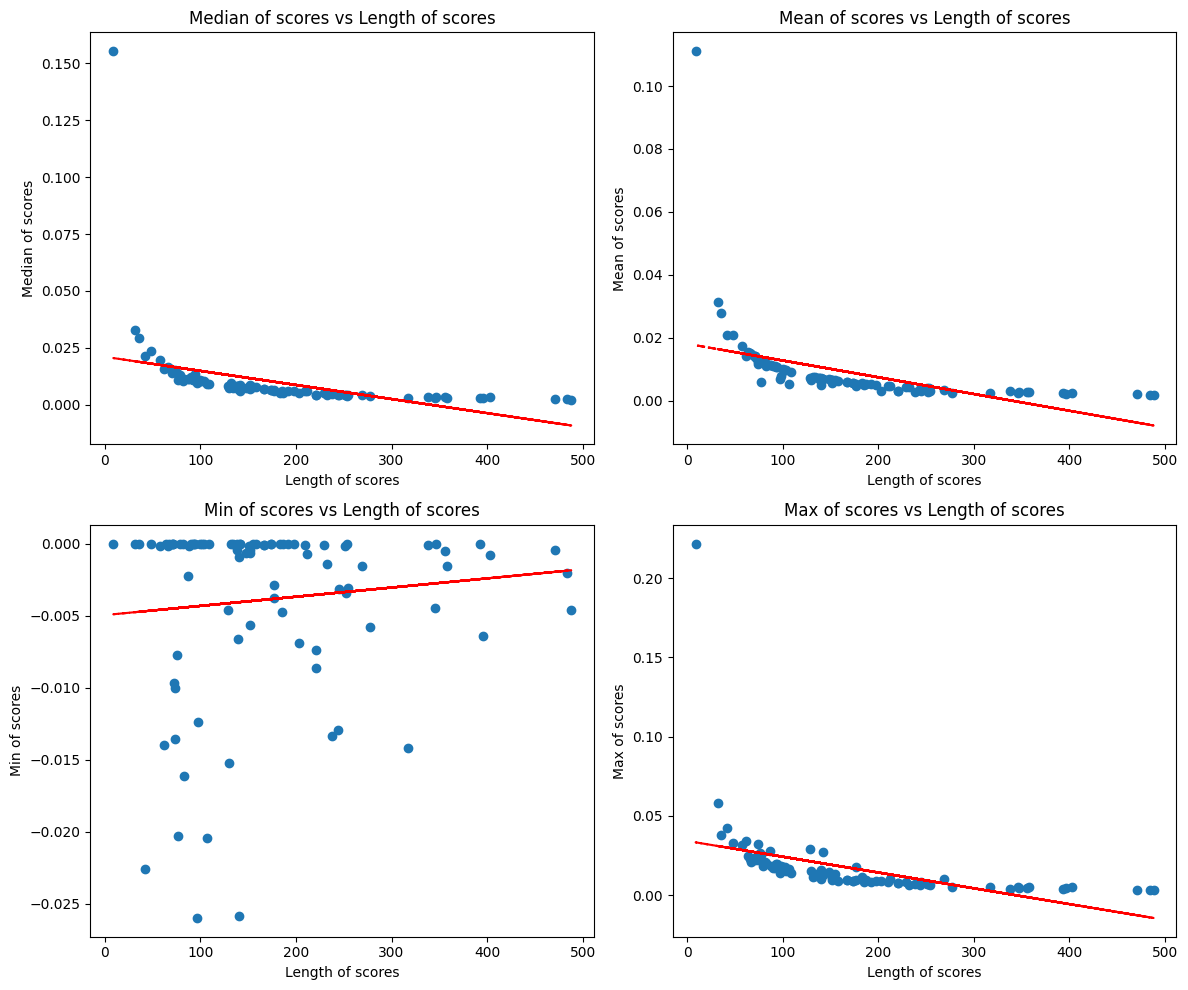

In [4]:
import matplotlib.pyplot as plt

x_values = [len(imp.scores) for imp in importance]

y_median = [np.median(imp.scores) for imp in importance]
y_mean = [np.mean(imp.scores) for imp in importance]
y_min = [min(imp.scores)[0] for imp in importance]
y_max = [max(imp.scores)[0] for imp in importance]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(x_values, y_median)
plt.xlabel("Length of scores")
plt.ylabel("Median of scores")
plt.title("Median of scores vs Length of scores")
z = np.polyfit(x_values, y_median, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 2)
plt.scatter(x_values, y_mean)
plt.xlabel("Length of scores")
plt.ylabel("Mean of scores")
plt.title("Mean of scores vs Length of scores")
z = np.polyfit(x_values, y_mean, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 3)
plt.scatter(x_values, y_min)
plt.xlabel("Length of scores")
plt.ylabel("Min of scores")
plt.title("Min of scores vs Length of scores")
z = np.polyfit(x_values, y_min, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 4)
plt.scatter(x_values, y_max)
plt.xlabel("Length of scores")
plt.ylabel("Max of scores")
plt.title("Max of scores vs Length of scores")
z = np.polyfit(x_values, y_max, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.tight_layout()
plt.show()

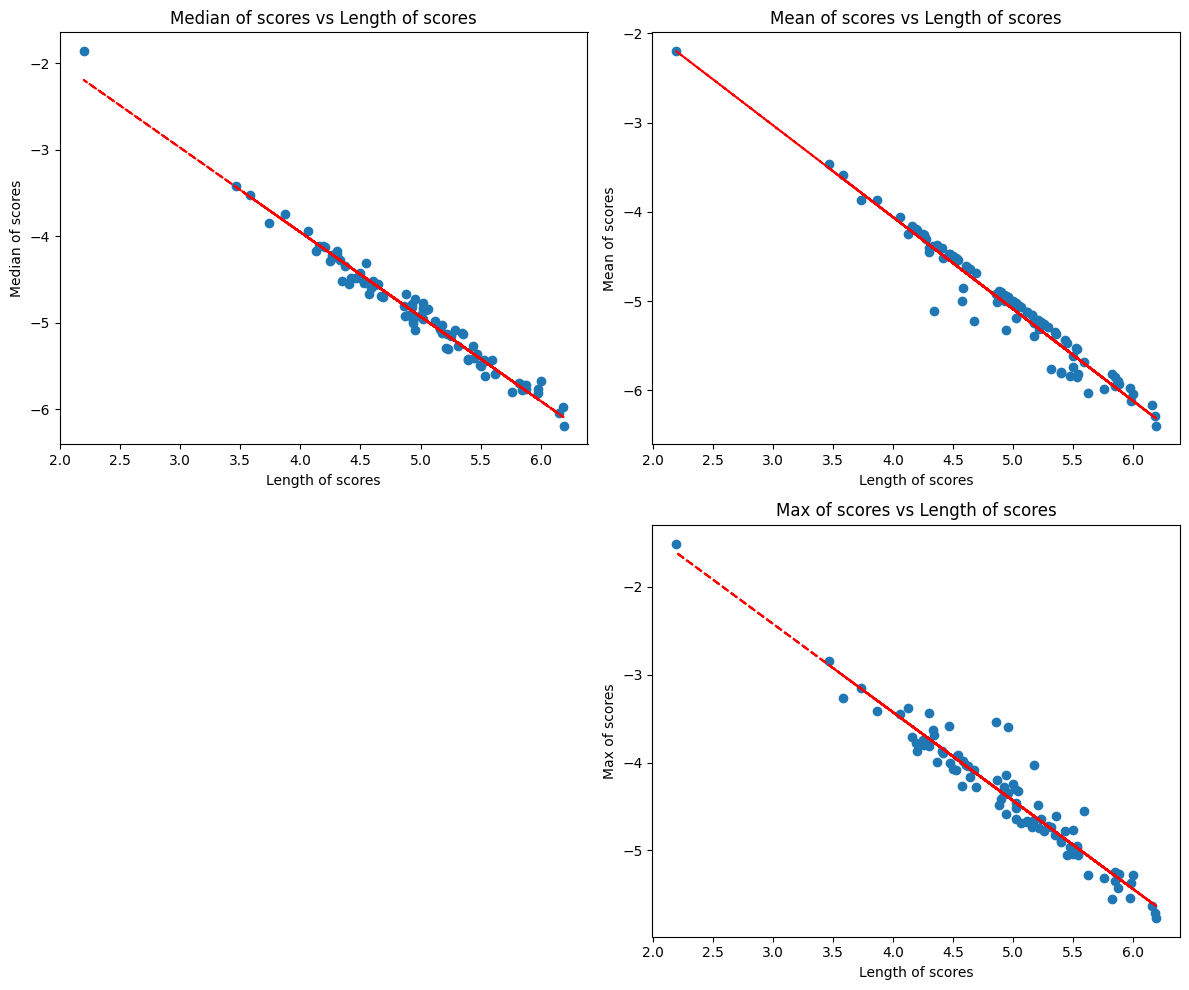

In [19]:
import matplotlib.pyplot as plt

x_values = np.log([len(imp.scores) for imp in importance])

y_median = [np.log(np.median(imp.scores)) for imp in importance]
y_mean =   [np.log(np.mean(imp.scores)) for imp in importance]
#y_min =    [np.log(min(imp.scores)[0]) for imp in importance]
y_max =    [np.log(max(imp.scores)[0]) for imp in importance]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(x_values, y_median)
plt.xlabel("Length of scores")
plt.ylabel("Median of scores")
plt.title("Median of scores vs Length of scores")
z = np.polyfit(x_values, y_median, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 2)
plt.scatter(x_values, y_mean)
plt.xlabel("Length of scores")
plt.ylabel("Mean of scores")
plt.title("Mean of scores vs Length of scores")
z = np.polyfit(x_values, y_mean, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

#plt.subplot(2, 2, 3)
#plt.scatter(x_values, y_min)
#plt.xlabel("Length of scores")
#plt.ylabel("Min of scores")
#plt.title("Min of scores vs Length of scores")
#z = np.polyfit(x_values, y_min, 1)
#p = np.poly1d(z)
#plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 4)
plt.scatter(x_values, y_max)
plt.xlabel("Length of scores")
plt.ylabel("Max of scores")
plt.title("Max of scores vs Length of scores")
z = np.polyfit(x_values, y_max, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.tight_layout()
plt.show()

In [20]:
print(pearsonr(np.log([np.median(imp.scores) for imp in importance]),np.log([len(imp.scores) for imp in importance])) )
print(pearsonr(np.log([np.mean(imp.scores) for imp in importance]  ),np.log([len(imp.scores) for imp in importance])) )
print(pearsonr(np.log([min(imp.scores)[0] for imp in importance]   ),np.log([len(imp.scores) for imp in importance])) )
print(pearsonr(np.log([max(imp.scores)[0] for imp in importance]   ),np.log([len(imp.scores) for imp in importance])) )

PearsonRResult(statistic=-0.988395222179103, pvalue=1.2322290389081178e-74)
PearsonRResult(statistic=-0.9782614908463839, pvalue=1.3387660040586274e-62)
PearsonRResult(statistic=nan, pvalue=nan)
PearsonRResult(statistic=-0.963591687457927, pvalue=9.03582141967375e-53)


invalid value encountered in log


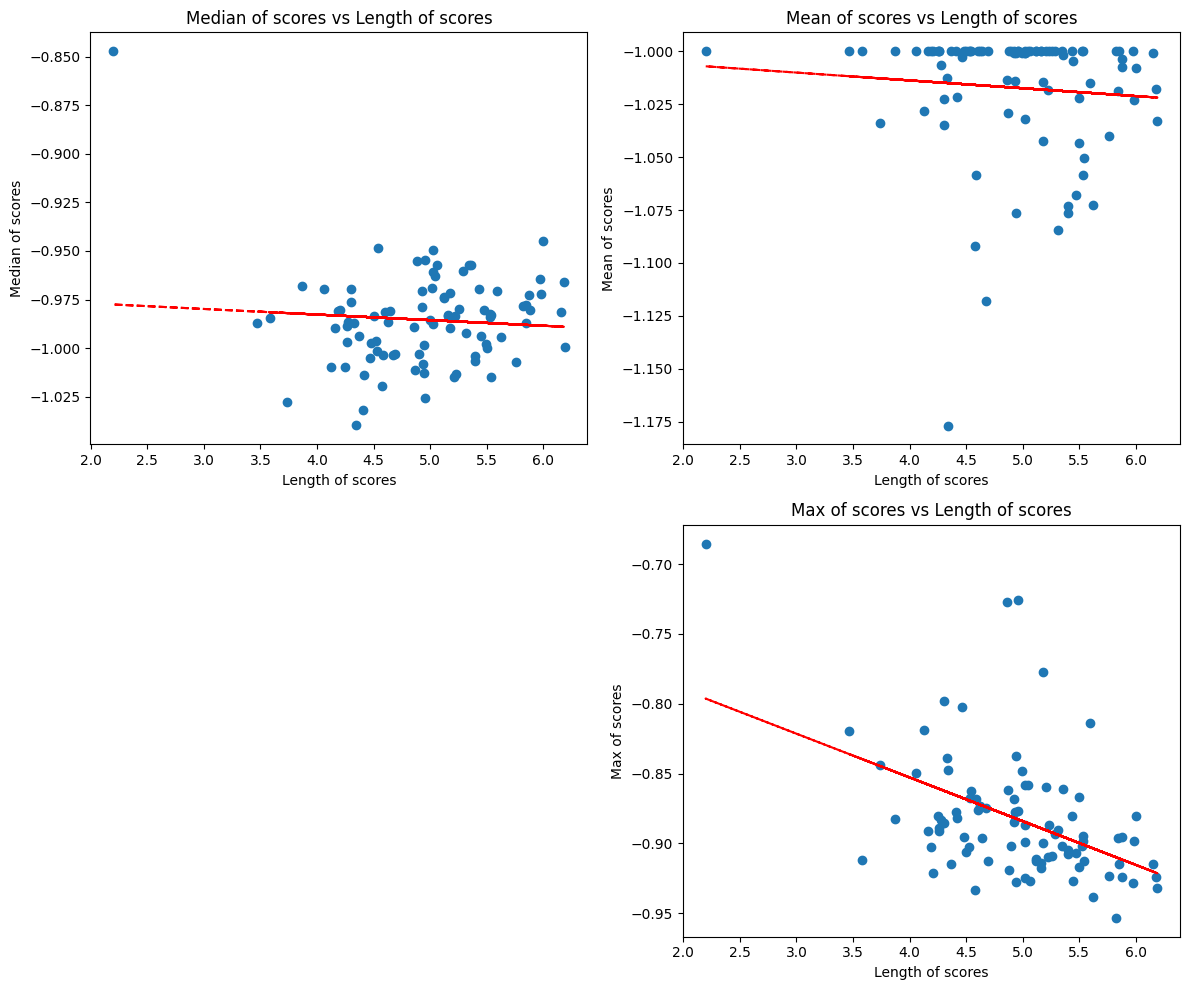

In [50]:
import matplotlib.pyplot as plt

x_values = np.log([len(imp.scores) for imp in importance])

y_median = [np.log(np.median(imp.scores))/np.log(len(imp.scores)) for imp in importance]
y_mean =   [np.log(np.mean(imp.scores))/np.log(len(imp.scores)) for imp in importance]
#y_min =    [np.log(min(imp.scores)[0]) for imp in importance]
y_max =    [np.log(max(imp.scores)[0])/np.log(len(imp.scores)) for imp in importance]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(x_values, y_median)
plt.xlabel("Length of scores")
plt.ylabel("Median of scores")
plt.title("Median of scores vs Length of scores")
z = np.polyfit(x_values, y_median, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 2)
plt.scatter(x_values, y_mean)
plt.xlabel("Length of scores")
plt.ylabel("Mean of scores")
plt.title("Mean of scores vs Length of scores")
z = np.polyfit(x_values, y_mean, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

#plt.subplot(2, 2, 3)
#plt.scatter(x_values, y_min)
#plt.xlabel("Length of scores")
#plt.ylabel("Min of scores")
#plt.title("Min of scores vs Length of scores")
#z = np.polyfit(x_values, y_min, 1)
#p = np.poly1d(z)
#plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 4)
plt.scatter(x_values, y_max)
plt.xlabel("Length of scores")
plt.ylabel("Max of scores")
plt.title("Max of scores vs Length of scores")
z = np.polyfit(x_values, y_max, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.tight_layout()
plt.show()

In [32]:
minLen = min([len(imp.scores) for imp in importance])
minLen

9

In [48]:
print(pearsonr([np.log(np.median(imp.scores))/np.log(len(imp.scores)) for imp in importance],np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([np.log(np.mean(imp.scores))/np.log(len(imp.scores)) for imp in importance]  ,np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([np.log(max(imp.scores)[0])/np.log(len(imp.scores)) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([np.log(max(imp.scores)[0])/np.log(len(imp.scores)-(minLen-2)) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([np.log(max(imp.scores)[0])/np.log(len(imp.scores)/1.8) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([max(imp.scores)[0]*len(imp.scores) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )

PearsonRResult(statistic=-0.07975203552056256, pvalue=0.4523716296970344)
PearsonRResult(statistic=-0.08148035163709824, pvalue=0.44260244722706865)
PearsonRResult(statistic=-0.4652996103846186, pvalue=3.365797501866034e-06)
PearsonRResult(statistic=0.38370218688842844, pvalue=0.00017371311969535978)
PearsonRResult(statistic=-0.025467417626285186, pvalue=0.8106216708821308)
PearsonRResult(statistic=-0.019799677741220375, pvalue=0.8522219603326803)


In [55]:
print(pearsonr([np.median(imp.scores)*len(imp.scores) for imp in importance],np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([np.mean(imp.scores)*len(imp.scores) for imp in importance]  ,np.log([len(imp.scores) for imp in importance])) )
print(pearsonr([max(imp.scores)[0]*len(imp.scores) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )

print(pearsonr([np.median(imp.scores)*len(imp.scores) for imp in importance],[len(imp.scores) for imp in importance]) )
print(pearsonr([np.mean(imp.scores)*len(imp.scores) for imp in importance]  ,[len(imp.scores) for imp in importance]) )
print(pearsonr([max(imp.scores)[0]*len(imp.scores) for imp in importance]   ,[len(imp.scores) for imp in importance]) )

print(spearmanr([np.median(imp.scores)*len(imp.scores) for imp in importance],np.log([len(imp.scores) for imp in importance])) )
print(spearmanr([np.mean(imp.scores)*len(imp.scores) for imp in importance]  ,np.log([len(imp.scores) for imp in importance])) )
print(spearmanr([max(imp.scores)[0]*len(imp.scores) for imp in importance]   ,np.log([len(imp.scores) for imp in importance])) )

print(spearmanr([np.median(imp.scores)*len(imp.scores) for imp in importance],[len(imp.scores) for imp in importance]) )
print(spearmanr([np.mean(imp.scores)*len(imp.scores) for imp in importance]  ,[len(imp.scores) for imp in importance]) )
print(spearmanr([max(imp.scores)[0]*len(imp.scores) for imp in importance]   ,[len(imp.scores) for imp in importance]) )

PearsonRResult(statistic=0.15355759668686145, pvalue=0.14615975114312613)
PearsonRResult(statistic=-0.16530016468949624, pvalue=0.11738197812898744)
PearsonRResult(statistic=-0.019799677741220375, pvalue=0.8522219603326803)
PearsonRResult(statistic=0.2628792129548841, pvalue=0.011819549251636873)
PearsonRResult(statistic=-0.13762362246676074, pvalue=0.1932937576187554)
PearsonRResult(statistic=-0.06450194176175077, pvalue=0.5435613304244938)
SignificanceResult(statistic=0.27712057119232547, pvalue=0.00782996561564325)
SignificanceResult(statistic=-0.2609298159963415, pvalue=0.012484665571375578)
SignificanceResult(statistic=-0.026382955037793452, pvalue=0.8039476391159702)
SignificanceResult(statistic=0.27712057119232547, pvalue=0.00782996561564325)
SignificanceResult(statistic=-0.2609298159963415, pvalue=0.012484665571375578)
SignificanceResult(statistic=-0.026382955037793452, pvalue=0.8039476391159702)


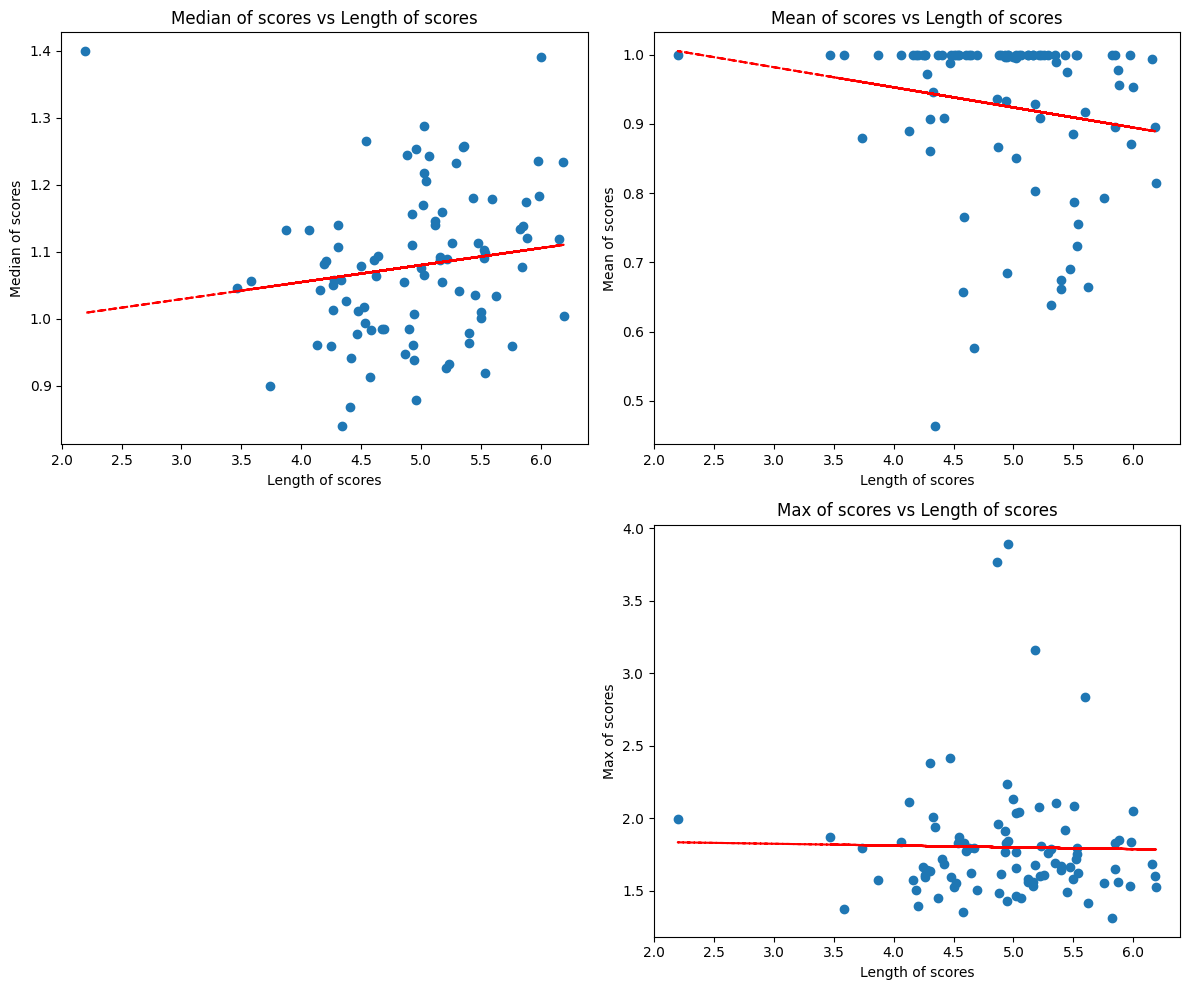

In [52]:
import matplotlib.pyplot as plt

x_values = np.log([len(imp.scores) for imp in importance])

y_median = [np.median(imp.scores)*len(imp.scores) for imp in importance]
y_mean =   [np.mean(imp.scores)*len(imp.scores) for imp in importance]
#y_min =    [np.log(min(imp.scores)[0]) for imp in importance]
y_max =    [max(imp.scores)[0]*len(imp.scores) for imp in importance]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(x_values, y_median)
plt.xlabel("Length of scores")
plt.ylabel("Median of scores")
plt.title("Median of scores vs Length of scores")
z = np.polyfit(x_values, y_median, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 2)
plt.scatter(x_values, y_mean)
plt.xlabel("Length of scores")
plt.ylabel("Mean of scores")
plt.title("Mean of scores vs Length of scores")
z = np.polyfit(x_values, y_mean, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

#plt.subplot(2, 2, 3)
#plt.scatter(x_values, y_min)
#plt.xlabel("Length of scores")
#plt.ylabel("Min of scores")
#plt.title("Min of scores vs Length of scores")
#z = np.polyfit(x_values, y_min, 1)
#p = np.poly1d(z)
#plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 4)
plt.scatter(x_values, y_max)
plt.xlabel("Length of scores")
plt.ylabel("Max of scores")
plt.title("Max of scores vs Length of scores")
z = np.polyfit(x_values, y_max, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.tight_layout()
plt.show()

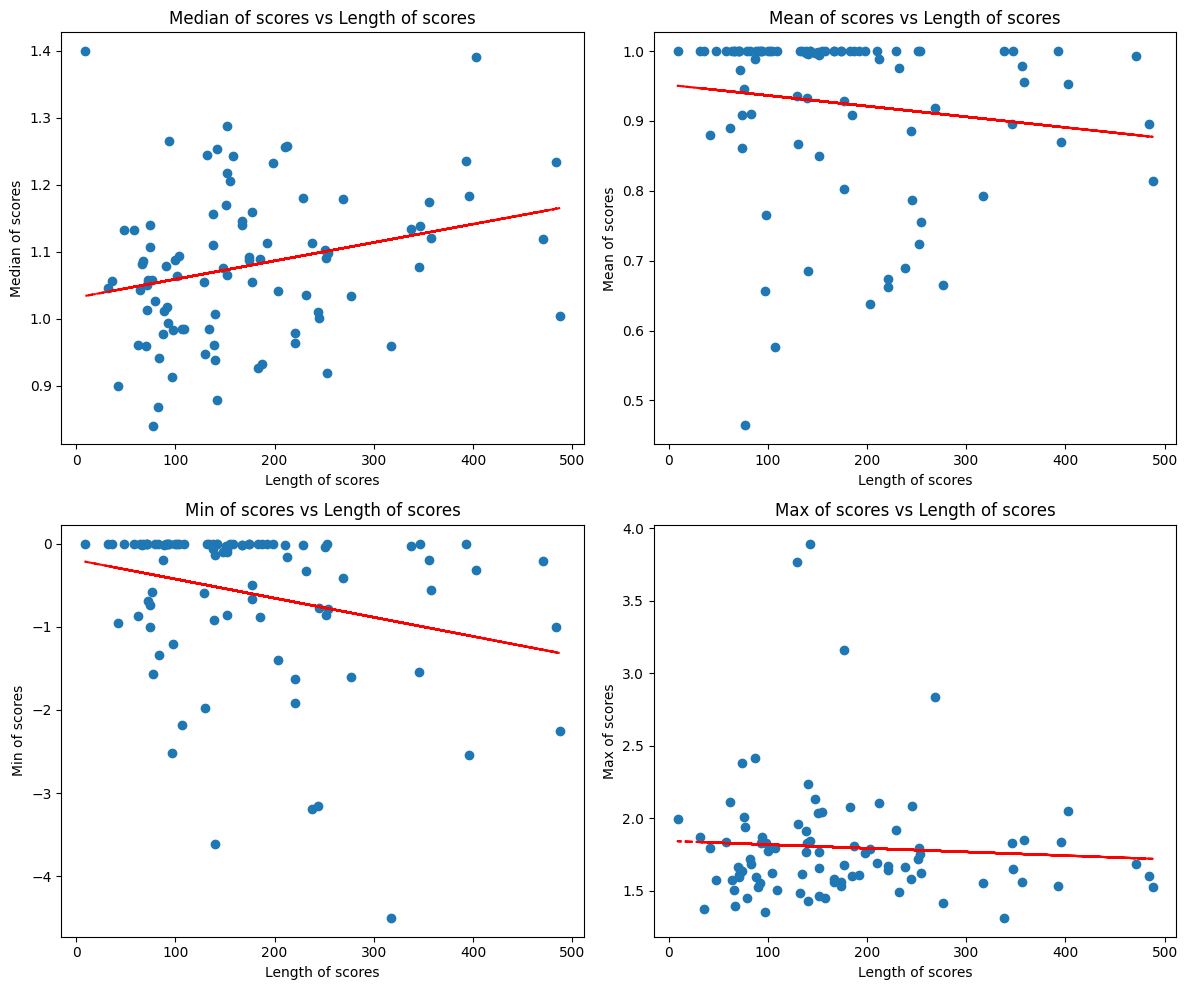

In [56]:
import matplotlib.pyplot as plt

x_values = [len(imp.scores) for imp in importance]

y_median = [np.median(imp.scores)*len(imp.scores) for imp in importance]
y_mean =   [np.mean(imp.scores)*len(imp.scores) for imp in importance]
y_min =    [min(imp.scores)[0]*len(imp.scores) for imp in importance]
y_max =    [max(imp.scores)[0]*len(imp.scores) for imp in importance]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(x_values, y_median)
plt.xlabel("Length of scores")
plt.ylabel("Median of scores")
plt.title("Median of scores vs Length of scores")
z = np.polyfit(x_values, y_median, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 2)
plt.scatter(x_values, y_mean)
plt.xlabel("Length of scores")
plt.ylabel("Mean of scores")
plt.title("Mean of scores vs Length of scores")
z = np.polyfit(x_values, y_mean, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 3)
plt.scatter(x_values, y_min)
plt.xlabel("Length of scores")
plt.ylabel("Min of scores")
plt.title("Min of scores vs Length of scores")
z = np.polyfit(x_values, y_min, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.subplot(2, 2, 4)
plt.scatter(x_values, y_max)
plt.xlabel("Length of scores")
plt.ylabel("Max of scores")
plt.title("Max of scores vs Length of scores")
z = np.polyfit(x_values, y_max, 1)
p = np.poly1d(z)
plt.plot(x_values, p(x_values), "r--")

plt.tight_layout()
plt.show()